In [1]:
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.abspath(''), '..'))
from cmm.ffxml import ForceFieldXML
from cmm.topology import Topology
from cmm.units import BOHR2NM, BOHR2ANG, HARTREE2KCAL
from cmm.system import System
from typing import Dict, Tuple, List

import openmm.app as app
from ase.io import read

In [2]:
torch.set_default_dtype(torch.float64)
device = "cpu" #torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ff_path = os.path.join(os.path.abspath(''), '../scripts/ion_water_refit.xml')
ff = ForceFieldXML(ff_path, device=device)

In [31]:
h2o_f_dimer_path = os.path.join(os.path.abspath(''), 'data/h2o_f_dimer.pdb')
h2o_cl_dimer_path = os.path.join(os.path.abspath(''), 'data/h2o_cl_dimer.pdb')

# Parameterize system using fluorine #
h2o_f_pdb = app.PDBFile(h2o_cl_dimer_path)
top = Topology.fromOpenmm(h2o_f_pdb.topology, device)
system = ff.parametrize(top, use_fd_morse=True, cutoff_sr=6.0, use_lr_dispersion=True, use_hardness_change=False, use_ewald=False, use_polarization_extrapolation=False)

h2o_cl_pdb = app.PDBFile(h2o_cl_dimer_path)
coords = torch.tensor(h2o_cl_pdb.getPositions(asNumpy=True)._value / BOHR2NM, device=device, requires_grad=True)
box = torch.tensor([[vec.x / BOHR2NM, vec.y / BOHR2NM, vec.z / BOHR2NM] for vec in h2o_cl_pdb.topology.getPeriodicBoxVectors()], device=device, requires_grad=True)

energies = system.getEnergy(coords, box)

energies['total'].backward()
print(coords.grad * HARTREE2KCAL / BOHR2ANG)

for key in energies.keys():
    print(f"{key:} {energies[key] * HARTREE2KCAL:.4f}")

#calc = CMMCalculator(system, top, coords, box)

tensor([[ 0.4166, -0.6339, -0.5588],
        [-0.2496,  0.3029,  0.2441],
        [ 0.0276,  0.3728,  0.4504],
        [-0.1946, -0.0418, -0.1358]])
bond 0.1691
angle 0.2089
torsion 0.0000
bond_bond 0.0014
bond_angle -0.0524
angle_angle 0.0000
torsion_bond 0.0000
torsion_angle 0.0000
torsion_angle_angle 0.0000
perm_elec -18.5094
pol -1.0346
ct_direct -7.7462
xpol 0.6367
pauli 13.8002
disp -2.8514
total -15.3778


In [19]:
def get_default_schedule_params():
    return {
            "Electrostatics": [
                ('ChargePenetration', 'b_elec', 1e15),
                ('ChargePenetration', 'Z', 0.0),
                ('Multipoles', 'mono', 0.0),
                ('Multipoles', 'dx',   0.0),
                ('Multipoles', 'dy',   0.0),
                ('Multipoles', 'dz',   0.0),
                ('Multipoles', 'q20',  0.0),
                ('Multipoles', 'q21c', 0.0),
                ('Multipoles', 'q21s', 0.0),
                ('Multipoles', 'q22c', 0.0),
                ('Multipoles', 'q22s', 0.0),
            ],
            "Polarization": [
                ('ExchangePolarization', 'b_xpol', 1e15),
                ('Polarization', 'eta', 0.0),
                ('Polarization', 'alpha_xx', 1e-10),
                ('Polarization', 'alpha_yy', 1e-10),
                ('Polarization', 'alpha_zz', 1e-10),
                ('Polarization', 'alpha_damp_max', 0.0),
                ('Polarization', 'alpha_damp_exponent', 0.0),
                ('ExchangePolarization', 'q_xpol', 0.0),
                ('ExchangePolarization', 'Kdipo_xpol', 0.0),
                ('ExchangePolarization', 'Kquad_xpol', 0.0),
            ],
            "Pauli": [
                ('Pauli', 'b_pauli', 1e15),
                ('Pauli', 'q_pauli', 0.0),
                ('Pauli', 'Kdipo_pauli', 0.0),
                ('Pauli', 'Kquad_pauli', 0.0),
            ],
            "Dispersion": [
                ('Dispersion', 'b_disp', 1e15),
                ('Dispersion', 'C6_disp', 0.0),
            ],
            "ChargeTransfer": [
                ('ChargeTransfer', 'b_ct', 1e15),
                ('ChargeTransfer', 'q_ct_acc', 0.0),
                ('ChargeTransfer', 'q_ct_don', 0.0),
                ('ChargeTransfer', 'Kdipo_ct_acc', 0.0),
                ('ChargeTransfer', 'Kdipo_ct_don', 0.0),
                ('ChargeTransfer', 'Kquad_ct_acc', 0.0),
                ('ChargeTransfer', 'Kquad_ct_don', 0.0),
                ('ChargeTransfer', 'eps_ct', 0.0),
            ]
        }
class AlchemicalSystem:
    def __init__(self,
        system: System,
        schedule: Dict['str', Tuple[int, int, int]], # interaction_type : atomic index, start, stop
        schedule_params: Dict['str', List[Tuple[str, str, float]]]=get_default_schedule_params()
    ):
        self.system = system
        self.schedule = schedule
        # NOTE(JOE): The parameters to turn off in the above defaults
        # do not account for bonded interactions or bonded parameters
        # which modify intermolecular parameters. So, for electrostatics
        # in water one would have to also turn off charge flux params.
        self.schedule_params = schedule_params
        self._store_initial_values()

    def _store_initial_values(self):
        # NOTE(JOE): Currently it is assumed that only one atom will be changed.
        # In general one might want to change every atom of a type of more than
        # one type. One also might want these different atoms to move towards
        # different targets. Will have to implement this in the future.
        self._initial_params = {}
        for key in self.schedule.keys():
            if key in self.schedule_params:
                atomic_index , _, _ = self.schedule[key]
                
                scheduled_params = self.schedule_params[key]
                for param_tuple in scheduled_params:
                    parameterizer, param_name, _ = param_tuple
                    atom_type_index = self.system.parametrizers[parameterizer].params['paramIndices'][atomic_index]
                    self._initial_params[param_name] = self.system.parametrizers[parameterizer].params[param_name][atom_type_index].item()
            else:
                raise KeyError(f"The key {key} in schedule does not exist in the schedule_params dictionary so we do not know what parameters to change to turn off this interaction.")

    def _interpolate(self, initial: float, target: float, t: float, interpolation_func=None):
        t = max(0, min(1, t)) # clamp t to [0,1]
        if interpolation_func is None:
            interpolation_func = self._linear_interpolation
        return interpolation_func(initial, target, t)

    def _linear_interpolation(self, initial: float, target: float, t: float):
        return initial + (target - initial) * t

    def _log_linear_interpolation(self, initial: float, target: float, t: float):
        log_value = np.log(initial) + (np.log(target) - np.log(initial)) * t
        return np.exp(log_value)

    def _update_parameters(self, step_num: int):
        for key in self.schedule.keys():
            atomic_index, start, stop = self.schedule[key]
            if step_num > stop:
                continue
            t = (step_num - start) / (stop - start)
            if start <= step_num and step_num <= stop:
                scheduled_params = self.schedule_params[key]
                for param_tuple in scheduled_params:
                    parameterizer, param_name, target = param_tuple
                    
                    # Get current parameter value by interpolation and store it #
                    interp_func = self._linear_interpolation
                    if 'b_' in param_name:
                        interp_func = self._log_linear_interpolation
                    current_value = self._interpolate(self._initial_params[param_name], target, t, interpolation_func=interp_func)
                    atom_type_index = self.system.parametrizers[parameterizer].params['paramIndices'][atomic_index]
                    self.system.parametrizers[parameterizer].params[param_name][atom_type_index] = current_value

In [20]:
def create_alchemical_system_atom_type_transformation(
        system: System, schedule: Dict['str', Tuple[int, int, int]],
        target_type: str
    ):
    schedule_params = get_default_schedule_params()
    for key in schedule.keys():
        if key in schedule_params:
            scheduled_params = schedule_params[key]
            for (i, param_tuple) in enumerate(scheduled_params):
                parameterizer, param_name, _ = param_tuple
                target_type_index = system.parametrizers[parameterizer].typesAsDict[target_type]
                schedule_params[key][i] = (
                    parameterizer, param_name,
                    system.parametrizers[parameterizer].params[param_name][target_type_index].item()
                )
    
    return AlchemicalSystem(system, schedule, schedule_params)

In [21]:
system.parametrizers['ChargePenetration'].typesAsDict

{'ow': 0,
 'hw': 1,
 'li+': 2,
 'na+': 3,
 'k+': 4,
 'rb+': 5,
 'cs+': 6,
 'f-': 7,
 'cl-': 8,
 'br-': 9,
 'i-': 10,
 'mg2+': 11,
 'ca2+': 12}

In [22]:
system.parametrizers['ChargePenetration'].params

{'atomIndices': tensor([0, 1, 2, 3]),
 'paramIndices': tensor([0, 1, 1, 7]),
 'Z': tensor([ 5.5473,  1.0031,  1.2445,  2.1413,  4.0501,  6.6744,  9.2264,  5.6606,
         17.0000, 35.0000, 53.0000,  3.0535,  4.9978]),
 'b_elec': tensor([2.3635, 2.5154, 2.2706, 2.1695, 1.9016, 1.9781, 1.6803, 2.3328, 1.9314,
         1.8188, 1.8957, 1.3759, 2.1212])}

In [23]:
schedule = {
    "Electrostatics": (3, 0, 20),
    "Polarization": (3, 0, 20),
    "Pauli": (3, 0, 20),
    "Dispersion": (3, 0, 20),
    "ChargeTransfer": (3, 0, 20),
}

In [24]:
#alchemical_system = AlchemicalSystem(system, schedule)
#alchemical_system._update_parameters(20)
#print(alchemical_system.system.parametrizers["ChargePenetration"].params['b_elec'])
#print(alchemical_system.system.parametrizers["Multipoles"].params['mono'])
#print(alchemical_system.system.parametrizers["Dispersion"].params['b_disp'])

In [25]:
alchemical_system_2 = create_alchemical_system_atom_type_transformation(system, schedule, 'cl-')

In [26]:
alchemical_system_2._update_parameters(0)
print(alchemical_system_2.system.parametrizers["ChargePenetration"].params['b_elec'])
print(alchemical_system_2.system.parametrizers["Multipoles"].params['mono'])
print(alchemical_system_2.system.parametrizers["Dispersion"].params['C6_disp'])

tensor([2.3635, 2.5154, 2.2706, 2.1695, 1.9016, 1.9781, 1.6803, 2.3328, 1.9314,
        1.8188, 1.8957, 1.3759, 2.1212])
tensor([-0.3909,  0.1954,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000,  2.0000,  2.0000])
tensor([3.5829e+01, 1.9895e+00, 6.1564e-01, 5.4973e+00, 4.6024e+01, 6.3124e+01,
        1.7074e+02, 1.4609e+02, 6.6178e+02, 1.1169e+03, 1.3593e+03, 3.9108e+00,
        2.5576e+01])


In [27]:
modified_energies = alchemical_system_2.system.getEnergy(coords, box)
for key in modified_energies.keys():
    print(f"{key:} {modified_energies[key] * HARTREE2KCAL:.4f}")

bond 0.1020
angle 0.2089
torsion 0.0000
bond_bond 0.0014
bond_angle -0.0524
angle_angle 0.0000
torsion_bond 0.0000
torsion_angle 0.0000
torsion_angle_angle 0.0000
perm_elec -16.2283
pol -3.1120
ct_direct -2.1961
xpol -0.0035
pauli 4.3059
disp -1.5120
total -18.4863


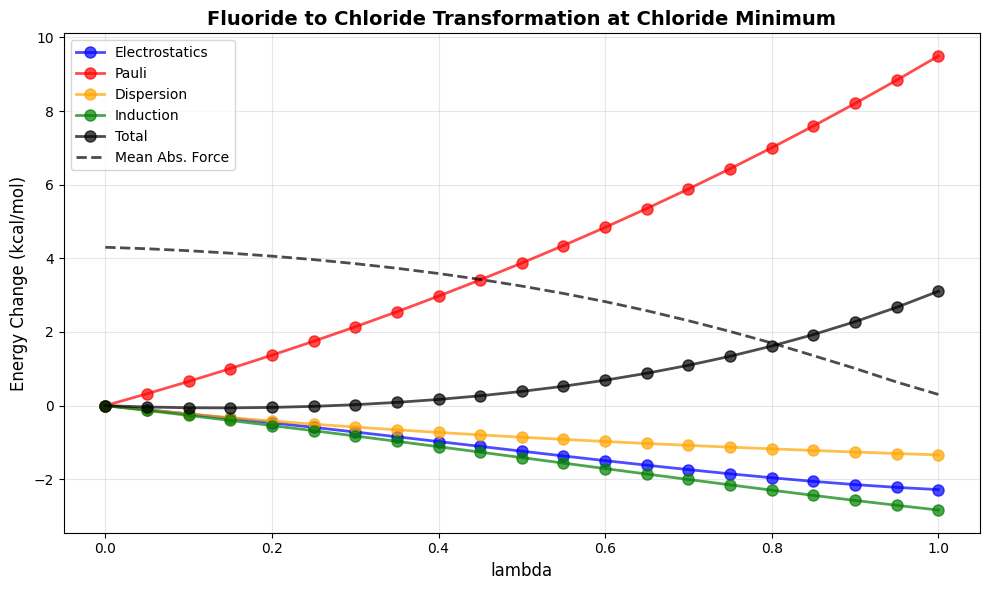

In [40]:
def plot_alchemical_energies():
    elec_energies = []
    disp_energies = []
    pauli_energies = []
    induction_energies = []
    total_energies = []
    mean_abs_force = []
    step = np.array([i for i in range(21)])
    for i in step:
        coords.grad = None # So that grads are not accumulated.
        alchemical_system_2._update_parameters(i)
        energies = alchemical_system_2.system.getEnergy(coords, box)
        energies['total'].backward()
        mean_abs_force.append(np.mean(np.abs(coords.grad.detach().cpu().numpy() * HARTREE2KCAL / BOHR2ANG)))
        

        elec_energies.append(energies['perm_elec'].item() * HARTREE2KCAL)
        disp_energies.append(energies['disp'].item() * HARTREE2KCAL)
        induction_energies.append((energies['pol'] + energies['xpol'] + energies['ct_direct']).item() * HARTREE2KCAL)
        pauli_energies.append(energies['pauli'].item() * HARTREE2KCAL)
        total_energies.append(energies['total'].item() * HARTREE2KCAL)


    elec_energies = np.array(elec_energies)
    disp_energies = np.array(disp_energies)
    pauli_energies = np.array(pauli_energies)
    induction_energies = np.array(induction_energies)
    total_energies = np.array(total_energies)
    mean_abs_force = np.array(mean_abs_force)

    lam_values = step / 20.0

    plt.figure(figsize=(10, 6))
    plt.plot(lam_values, elec_energies - elec_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='blue', markeredgecolor='blue', color='blue', alpha=0.7, label="Electrostatics")
    plt.plot(lam_values, pauli_energies - pauli_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='red', markeredgecolor='red', color='red', alpha=0.7, label="Pauli")
    plt.plot(lam_values, disp_energies - disp_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='orange', markeredgecolor='orange', color='orange', alpha=0.7, label="Dispersion")
    plt.plot(lam_values, induction_energies - induction_energies[0], 'o-', linewidth=2, markersize=8, 
        markerfacecolor='green', markeredgecolor='green', color='green', alpha=0.7, label="Induction")
    plt.plot(lam_values, total_energies - total_energies[0], 'o-', linewidth=2, markersize=8, 
            markerfacecolor='black', markeredgecolor='black', color='black', alpha=0.7, label="Total")
    plt.plot(lam_values, mean_abs_force, '--', linewidth=2, markersize=8, 
        markerfacecolor='black', markeredgecolor='black', color='black', alpha=0.7, label="Mean Abs. Force")

    plt.xlabel('lambda', fontsize=12)
    plt.ylabel('Energy Change (kcal/mol)', fontsize=12)
    plt.title('Fluoride to Chloride Transformation at Chloride Minimum', fontsize=14, fontweight='bold')

    plt.grid(True, alpha=0.3)

    plt.legend()

    plt.tight_layout()
    plt.show()

plot_alchemical_energies()